In [ ]:
import sys

PATH_TO_PYHARM = ".."
INPUT_FILE = "Thesis/model/Jeffcott.mat"
sys.path.append(PATH_TO_PYHARM)

In [2]:
import copy
import csv
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from scipy.io import loadmat

import pyHarm

## Input file

In [3]:
# ------------------ INPUT CONSTRUCTION ------------------ #
INP = {
    "analysis": {
        "FRF": {
            "study": "frf",
            "puls_inf": 1.0,
            "puls_start": 1.0,
            "puls_sup": 400.0,
            "ds0": 1e-1,
            "ds_min": 1e-12,
            "ds_max": 1e-1,
            "sign_ds": 1,
            "verbose": True,
            "stepsizer": "acceptance",
            "predictor": "tangent",
            "reductors": [
                {
                    "type": "globalHarmonic",
                    "nh_start": np.array([1]),
                    "err_admissible": 1e10,
                    "h_always_kept": np.array([1]),
                    "verbose": False,
                }
            ],
            "corrector": "arc_length",
            "preconditioner": "allgower",
            "stopper": "bounds",
            "solver": "scipyroot",
        }
    },
    "system": {
        "type": "Base",
        "nh": 1,
        "nti": 1024,
        "adim": {"status": True, "lc": 1.5e-4, "wc": 1.0},
    },
    "substructures": {"sub1": {"filename": INPUT_FILE, "ndofs": 4}},
    "connectors": {
        "loading_dir0": {
            "type": "GOForcing",
            "connect": {"sub1": [1]},
            "dirs": [0],
            "dto": 2,
            "phi": 0,
            "ho": 1,
            "amp": 50e-3,
        },
        "loading_dir1": {
            "type": "GOForcing",
            "connect": {"sub1": [1]},
            "dirs": [1],
            "dto": 2,
            "phi": np.pi / 2.0,
            "ho": 1,
            "amp": 50e-3,
        },
        "gap": {
            "type": "PenaltyBilateralGap",
            "connect": {"sub1": [4], "INTERNAL": [5]},
            "dirs": [0, 1],
            "g": 1.5e-4,
            "k": 1e8,
        },
    },
}

NRB_XY = pyHarm.Maestro(INP)

## Run analysis

In [4]:
NRB_XY.operate()

solution converged at om=1.0
solution converged at om=1.0999999828615175
solution converged at om=1.1999999623011017
solution converged at om=1.299999938006905
solution converged at om=1.3999999096668805
solution converged at om=1.4999998769687652
solution converged at om=1.599999839600064
solution converged at om=1.6999997972480327
solution converged at om=1.7999997495996605
solution converged at om=1.899999696341654
solution converged at om=1.999999637160421
solution converged at om=2.0999995717420514
solution converged at om=2.199999499772304
solution converged at om=2.299999420936586
solution converged at om=2.3999993349199387
solution converged at om=2.4999992414070187
solution converged at om=2.5999991400820828
solution converged at om=2.699999030628969
solution converged at om=2.7999989127310814
solution converged at om=2.899998786071372
solution converged at om=2.9999986503323246
solution converged at om=3.099998505195936
solution converged at om=3.1999983503437
solution conver

## Plot FRF

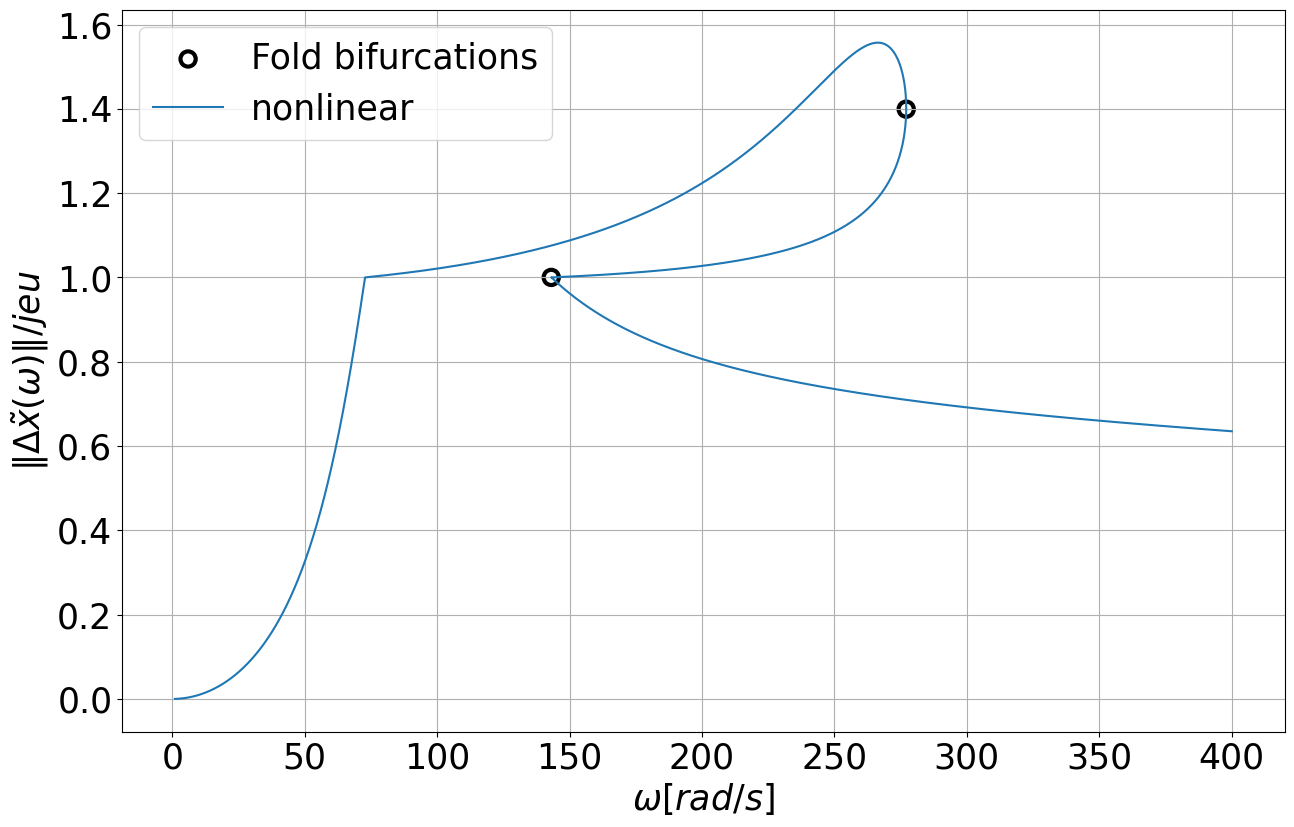

In [5]:
plt.style.use("default")
FONT_BASE = 25
width_fig = 15
ratio_fig = (width_fig, 1 / (16 / 10.0) * width_fig)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
plt.rc("xtick", labelsize=FONT_BASE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=FONT_BASE)  # fontsize of the tick labels
plt.rc("legend", fontsize=FONT_BASE)  # legend fontsize
plt.rc("axes", labelsize=FONT_BASE)
plt.rc("axes", titlesize=FONT_BASE + 5)  # fontsize of the title

style_plots_ref = {
    "frf_lin": {
        "linestyle": "dashed",
        "color": np.array([0, 0, 0]),
        "label": "Linear solution",
    },
    "frf_nl": {
        "linestyle": "solid",
        "linewidth": 2,
        "color": np.array([255, 140, 0]) / 255.0,
        "marker": ".",
        "label": "nonlinear solution",
    },
}

# Indices harmoniques des ddls d'intérêt
indices_selection_51 = ("sub1", 4, 0)
indices_selection_52 = ("sub1", 4, 1)
indices_selection_61 = ("sub1", 5, 0)
indices_selection_62 = ("sub1", 5, 1)
indexH_51 = NRB_XY.getIndex(*indices_selection_51)
indexH_52 = NRB_XY.getIndex(*indices_selection_52)
indexH_61 = NRB_XY.getIndex(*indices_selection_61)
indexH_62 = NRB_XY.getIndex(*indices_selection_62)

fig, ax = plt.subplots(figsize=ratio_fig)

from pyHarm.DynamicOperator import compute_DFT

DFTO = compute_DFT(NRB_XY.system.nti, NRB_XY.system.nh)

SA = [sol for sol in NRB_XY.nls["FRF"].SolList if sol.flag_accepted]
om = np.array([sol.x[-1] for sol in SA])

ampH = np.array(
    [
        np.linalg.norm(
            (
                np.sqrt(
                    ((sol.x[indexH_51] - sol.x[indexH_61]) @ DFTO["ft"]) ** 2
                    + ((sol.x[indexH_52] - sol.x[indexH_62]) @ DFTO["ft"]) ** 2
                )
            )
            @ DFTO["tf"]
        )
        for sol in SA
    ]
)

SA_bifurc = [
    sol for sol in NRB_XY.nls["FRF"].SolList if (sol.flag_accepted and sol.flag_bifurcation)
]
om_bifurc = np.array([sol.x[-1] for sol in SA_bifurc])
ampH_bifurc = np.array(
    [
        np.linalg.norm(
            (
                np.sqrt(
                    ((sol.x[indexH_51] - sol.x[indexH_61]) @ DFTO["ft"]) ** 2
                    + ((sol.x[indexH_52] - sol.x[indexH_62]) @ DFTO["ft"]) ** 2
                )
            )
            @ DFTO["tf"]
        )
        for sol in SA_bifurc
    ]
)

ax.scatter(
    om_bifurc,
    ampH_bifurc,
    s=120,
    marker="o",
    color="k",
    facecolors="none",
    linewidth=3,
    label="Fold bifurcations",
)
ax.plot(om, ampH, label="nonlinear")
ax.set_xlabel("$\\omega [rad/s]$")
ax.set_ylabel(r"$\|\Delta \tilde{x}(\omega)\|/jeu$")
ax.legend()
ax.grid()

## Plot orbits

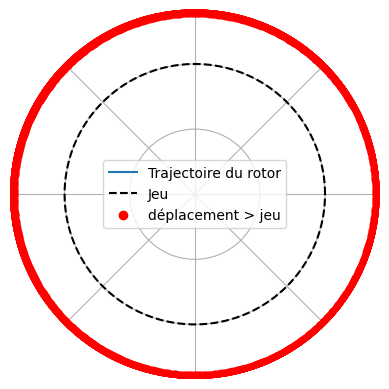

In [6]:
id = 0  # index de la bifurcation d'intérêt
dx = (SA_bifurc[id].x[indexH_51] - SA_bifurc[id].x[indexH_61]) @ DFTO["ft"]
dy = (SA_bifurc[id].x[indexH_52] - SA_bifurc[id].x[indexH_62]) @ DFTO["ft"]

# Conversion en coordonnées polaires
r = np.sqrt(dx**2 + dy**2)
theta = np.arctan2(dy, dx)

# Création de la figure en coordonnées polaires
fig = plt.figure()
ax = fig.add_subplot(111, projection="polar")

# Tracé de la trajectoire
ax.plot(theta, r, label="Trajectoire du rotor")
ax.plot(np.linspace(0, 2 * np.pi, len(r)), 1 * np.ones_like(r), "k--", label="Jeu")
ax.plot(theta[r > 1], r[r > 1], "ro", label="déplacement > jeu")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.spines["polar"].set_visible(False)
ax.legend(fontsize=10, loc=10)
plt.show()